# Sesión 2: resolución de EDPs mediante Redes Neuronales Informadas por la Física

## El mismo problema de Poisson en un recinto anular

Este cuaderno continúa directamente `FEM_Curso_01.ipynb`. Conservaremos el dominio, los datos, la convención de signo y la notación. La diferencia será la representación de la solución:

$$
\text{FEM:}
\qquad
u_{h}(\mathbf{x})
=
\sum_{j=1}^{N}U_{j}\varphi_{j}(\mathbf{x}),
$$

$$
\text{PINN:}
\qquad
u_{\theta}(\mathbf{x})
=
\operatorname{NN}_{\theta}(\mathbf{x}).
$$

En ambos casos buscamos una función que satisfaga una EDP y sus condiciones de contorno. FEM conduce a un sistema algebraico; una PINN conduce a un problema de optimización.

> **Idea central:** FEM y PINNs son dos familias distintas de aproximaciones funcionales, no dos problemas matemáticos diferentes.

## Objetivos de aprendizaje

Al finalizar el cuaderno deberías poder:

1. interpretar una red neuronal como una función $u_{\theta}(x,y)$;
2. calcular derivadas espaciales mediante autodiferenciación;
3. construir el Laplaciano $\Delta u_{\theta}$;
4. formular por separado los residuos interior, de Dirichlet y de Neumann;
5. entrenar una PINN con condiciones mixtas en un anillo;
6. distinguir pérdida de entrenamiento, residual independiente y error respecto a una referencia;
7. relacionar la PINN fuerte con la formulación variacional y Deep Ritz;
8. reconocer cuándo una PINN puede ser interesante en un problema inverso.

### Notación común

- dominio: $\Omega$;
- frontera: $\partial\Omega=\Gamma_{D}\cup\Gamma_{N}$;
- solución continua: $u$;
- aproximación FEM: $u_{h}$;
- solución neuronal: $u_{\theta}$;
- función test: $v$ o $v_{h}$;
- forma bilineal: $a(u,v)$;
- forma lineal: $L(v)$;
- residual interior: $r_{\Omega}$;
- pérdidas: $\mathcal{L}_{\Omega}$, $\mathcal{L}_{D}$ y $\mathcal{L}_{N}$.

## 0. Requisitos, reproducibilidad y tiempo de ejecución

Requisitos mínimos:

```bash
python -m pip install torch numpy scipy matplotlib "scikit-fem==12.0.2"
```

El entrenamiento se ha diseñado para CPU. `QUICK_MODE=True` utiliza una configuración breve para clase. El resultado de una PINN depende de la semilla, la arquitectura, el muestreo, los pesos de las pérdidas y el optimizador; por ello, una ejecución aislada no constituye un estudio de robustez.

In [ ]:
!python -m pip install torch numpy scipy matplotlib "scikit-fem==12.0.2"

In [1]:
import sys
import time
import random
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn

print(f"Python:      {sys.version.split()[0]}")
print(f"NumPy:       {np.__version__}")
print(f"SciPy:       {scipy.__version__}")
print(f"Matplotlib:  {matplotlib.__version__}")
print(f"PyTorch:     {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

QUICK_MODE = True
RUN_INVERSE_DEMO = False
print(f"Dispositivo: {DEVICE}; precisión: {DTYPE}; QUICK_MODE={QUICK_MODE}")

Python:      3.12.13
NumPy:       2.5.1
SciPy:       1.18.0
Matplotlib:  3.11.1
PyTorch:     2.13.0
CUDA disponible: False
Dispositivo: cpu; precisión: torch.float32; QUICK_MODE=True


# Parte I. Una red neuronal como función

## 1. De una entrada $(x,y)$ a una salida escalar

Una red neuronal feed-forward compone transformaciones afines y funciones de activación. Para una capa:

$$
\mathbf{z}^{(\ell+1)}
=
\sigma\!\left(W^{(\ell)}\mathbf{z}^{(\ell)}+\mathbf{b}^{(\ell)}\right).
$$

La red completa define una función parametrizada:

$$
u_{\theta}:\mathbb{R}^{2}\longrightarrow\mathbb{R},
\qquad
(x,y)\longmapsto u_{\theta}(x,y).
$$

El teorema de aproximación universal justifica, bajo hipótesis apropiadas, que una red suficientemente expresiva puede aproximar funciones continuas. No garantiza que el entrenamiento encuentre esa aproximación ni que satisfaga una EDP con precisión.

In [2]:
class MLP(nn.Module):
    """Perceptrón multicapa para representar u_theta(x, y)."""

    def __init__(self, input_dim=2, hidden_dim=32, hidden_layers=3, output_dim=1):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.Tanh()])
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, xy):
        return self.network(xy)


model_demo = MLP(hidden_dim=24, hidden_layers=3).to(DEVICE)
xy_demo = torch.tensor([[0.50, 0.20], [-0.40, 0.60]], device=DEVICE)
print(model_demo)
print("Entrada:")
print(xy_demo)
print("Salida u_theta:")
print(model_demo(xy_demo).detach())
print("Número de parámetros:", sum(p.numel() for p in model_demo.parameters()))

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=24, bias=True)
    (1): Tanh()
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): Tanh()
    (4): Linear(in_features=24, out_features=24, bias=True)
    (5): Tanh()
    (6): Linear(in_features=24, out_features=1, bias=True)
  )
)
Entrada:
tensor([[ 0.5000,  0.2000],
        [-0.4000,  0.6000]])
Salida u_theta:
tensor([[ 0.0695],
        [-0.1409]])
Número de parámetros: 1297


## 2. Comparación con FEM

En FEM, la familia aproximante viene fijada por la malla y las funciones de base:

$$
u_{h}=\sum_{j=1}^{N}U_{j}\varphi_{j}.
$$

En una red, la familia viene fijada por la arquitectura y la activación:

$$
u_{\theta}=\operatorname{NN}_{\theta}(x,y).
$$

| Aspecto | FEM | Red neuronal |
|---|---|---|
| Parámetros | coeficientes $U_{j}$ | pesos y sesgos $\theta$ |
| Representación | base local prefijada | composición no lineal |
| Geometría | malla | puntos y representación de la frontera |
| Cálculo | sistema algebraico | optimización |
| Derivadas | por elemento | autodiferenciación |

La analogía es útil, pero una MLP no es literalmente una “base” FEM: la dependencia respecto a $\theta$ es no lineal.

# Parte II. Autodiferenciación

## 3. Derivadas respecto a las coordenadas

PyTorch se usa normalmente para derivar una pérdida respecto a los parámetros. En una PINN también necesitamos derivar la salida respecto a las coordenadas:

$$
\frac{\partial u_{\theta}}{\partial x},
\qquad
\frac{\partial u_{\theta}}{\partial y},
$$

$$
\frac{\partial^{2}u_{\theta}}{\partial x^{2}},
\qquad
\frac{\partial^{2}u_{\theta}}{\partial y^{2}}.
$$

Para conservar el grafo y poder volver a derivar usamos `create_graph=True`.

In [3]:
def gradient_scalar_field(u, xy, create_graph=True):
    """Devuelve grad(u) para una salida escalar evaluada en xy."""
    return torch.autograd.grad(
        u,
        xy,
        grad_outputs=torch.ones_like(u),
        create_graph=create_graph,
        retain_graph=True,
    )[0]


def laplacian(model, xy, create_graph=True):
    """Calcula Delta u_theta punto a punto."""
    xy = xy.requires_grad_(True)
    u = model(xy)
    grad_u = gradient_scalar_field(u, xy, create_graph=True)

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]
    grad_u_x = gradient_scalar_field(u_x, xy, create_graph=create_graph)
    grad_u_y = gradient_scalar_field(u_y, xy, create_graph=create_graph)

    u_xx = grad_u_x[:, 0:1]
    u_yy = grad_u_y[:, 1:2]
    return u, grad_u, u_xx + u_yy

## 4. Verificación de la autodiferenciación

Antes de construir una PINN comprobamos las derivadas con una función conocida:

$$
u(x,y)=\sin(\pi x)\sin(\pi y),
$$

$$
\Delta u=-2\pi^{2}u.
$$

Esta prueba verifica el mecanismo de derivación, no el entrenamiento de la PINN.

In [4]:
class KnownFunction(nn.Module):
    def forward(self, xy):
        x = xy[:, 0:1]
        y = xy[:, 1:2]
        return torch.sin(torch.pi * x) * torch.sin(torch.pi * y)


known_model = KnownFunction()
xy_test = torch.tensor(
    [[0.20, 0.30], [0.45, 0.75], [0.80, 0.55]],
    device=DEVICE,
    requires_grad=True,
)
u_test, grad_test, lap_test = laplacian(known_model, xy_test)
lap_exact = -2.0 * torch.pi**2 * u_test
max_laplacian_defect = torch.max(torch.abs(lap_test - lap_exact)).item()

print("u:")
print(u_test.detach())
print("grad(u):")
print(grad_test.detach())
print("Delta u autodiferenciado:")
print(lap_test.detach())
print(f"Defecto máximo del Laplaciano: {max_laplacian_defect:.3e}")
assert max_laplacian_defect < 2.0e-5

u:
tensor([[0.4755],
        [0.6984],
        [0.5805]])
grad(u):
tensor([[ 2.0562,  1.0854],
        [ 0.3475, -2.1941],
        [-2.5103, -0.2889]])
Delta u autodiferenciado:
tensor([[ -9.3866],
        [-13.7859],
        [-11.4596]])
Defecto máximo del Laplaciano: 1.907e-06


# Parte III. El problema de Poisson en el anillo

## 5. EDP y condiciones de contorno

Conservamos exactamente el problema de `FEM_Curso_01.ipynb`:

$$
\Delta u=f
\qquad\text{en }\Omega,
$$

$$
u=g
\qquad\text{en }\Gamma_{D},
$$

$$
\nabla u\cdot\mathbf{n}=h
\qquad\text{en }\Gamma_{N},
$$

con

$$
f(x,y)=x,
\qquad
g(x,y)=\sin(\pi y),
\qquad
h(x,y)=\sqrt{x^{2}+1}.
$$

La frontera exterior es $\Gamma_{D}$ y la interior es $\Gamma_{N}$. En el agujero,

$$
\mathbf{n}(x,y)=-\frac{(x,y)}{R_{\mathrm{i}}}.
$$

In [5]:
R_INNER = 0.35
R_OUTER = 1.00


def source_torch(xy):
    return xy[:, 0:1]


def dirichlet_torch(xy):
    return torch.sin(torch.pi * xy[:, 1:2])


def neumann_torch(xy):
    return torch.sqrt(xy[:, 0:1]**2 + 1.0)


def inner_outward_normal(xy):
    radius = torch.linalg.norm(xy, dim=1, keepdim=True)
    return -xy / radius

## 6. Puntos interiores y de frontera

Una PINN no obliga a usar una malla volumétrica para evaluar la pérdida fuerte, pero sí necesita una estrategia de muestreo y una representación correcta de la geometría.

Para muestrear uniformemente en área en el anillo usamos

$$
r=\sqrt{R_{\mathrm{i}}^{2}+\xi\left(R_{\mathrm{o}}^{2}-R_{\mathrm{i}}^{2}\right)},
\qquad
\xi\sim\mathcal{U}(0,1).
$$

La raíz cuadrada evita concentrar artificialmente puntos cerca del agujero.

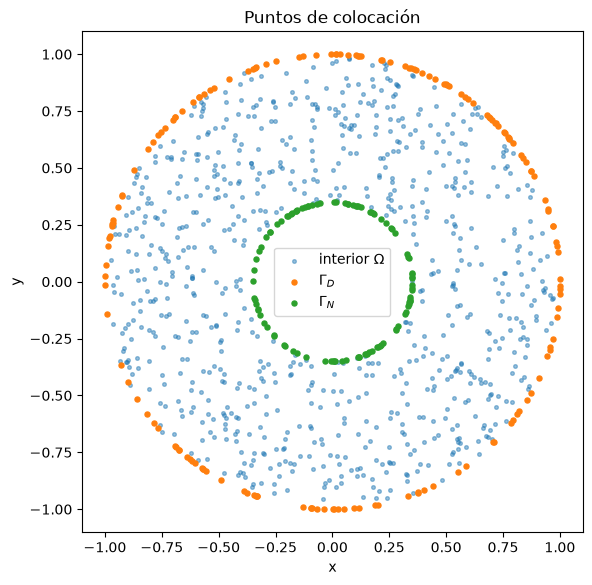

In [6]:
def sample_annulus_interior(n, generator=None):
    xi = torch.rand((n, 1), generator=generator, device=DEVICE, dtype=DTYPE)
    theta = 2.0 * torch.pi * torch.rand(
        (n, 1), generator=generator, device=DEVICE, dtype=DTYPE
    )
    radius = torch.sqrt(
        R_INNER**2 + xi * (R_OUTER**2 - R_INNER**2)
    )
    return torch.cat((radius * torch.cos(theta), radius * torch.sin(theta)), dim=1)


def sample_circle(radius, n, generator=None):
    theta = 2.0 * torch.pi * torch.rand(
        (n, 1), generator=generator, device=DEVICE, dtype=DTYPE
    )
    return torch.cat((radius * torch.cos(theta), radius * torch.sin(theta)), dim=1)


plot_generator = torch.Generator(device=DEVICE).manual_seed(SEED + 1)
xy_interior_plot = sample_annulus_interior(800, plot_generator).cpu().numpy()
xy_dirichlet_plot = sample_circle(R_OUTER, 160, plot_generator).cpu().numpy()
xy_neumann_plot = sample_circle(R_INNER, 100, plot_generator).cpu().numpy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(xy_interior_plot[:, 0], xy_interior_plot[:, 1], s=7, alpha=0.45, label=r"interior $\Omega$")
ax.scatter(xy_dirichlet_plot[:, 0], xy_dirichlet_plot[:, 1], s=13, label=r"$\Gamma_D$")
ax.scatter(xy_neumann_plot[:, 0], xy_neumann_plot[:, 1], s=13, label=r"$\Gamma_N$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Puntos de colocación")
ax.set_aspect("equal")
ax.legend()
plt.show()

# Parte IV. Construcción de la PINN

## 7. Residual de la EDP

La convención de signo es

$$
\Delta u=f.
$$

Por tanto, el residual interior correcto es

$$
r_{\Omega}(\mathbf{x};\theta)
=
f(\mathbf{x})+\Delta u_{\theta}(\mathbf{x}).
$$

La pérdida interior será

$$
\mathcal{L}_{\Omega}
=
\frac{1}{N_{\Omega}}
\sum_{i=1}^{N_{\Omega}}
\left|r_{\Omega}(\mathbf{x}_{i};\theta)\right|^{2}.
$$

## 8. Condiciones de contorno blandas

Para Dirichlet:

$$
\mathcal{L}_{D}
=
\frac{1}{N_{D}}
\sum_{j=1}^{N_{D}}
\left|u_{\theta}(\mathbf{x}_{j})-g(\mathbf{x}_{j})\right|^{2}.
$$

Para Neumann:

$$
\mathcal{L}_{N}
=
\frac{1}{N_{N}}
\sum_{k=1}^{N_{N}}
\left|
\nabla u_{\theta}(\mathbf{x}_{k})\cdot\mathbf{n}_{k}
-h(\mathbf{x}_{k})
\right|^{2}.
$$

Y la pérdida total:

$$
\mathcal{L}
=
\lambda_{\Omega}\mathcal{L}_{\Omega}
+
\lambda_{D}\mathcal{L}_{D}
+
\lambda_{N}\mathcal{L}_{N}.
$$

Imponemos Dirichlet de forma blanda para conservar un procedimiento general. No multiplicamos la red por un factor específico del anillo.

In [7]:
def pinn_loss(model, xy_interior, xy_dirichlet, xy_neumann, weights):
    # Residual interior: f + Delta u_theta.
    _, _, lap_u = laplacian(model, xy_interior)
    residual_interior = lap_u - source_torch(xy_interior)
    loss_interior = torch.mean(residual_interior**2)

    # Dirichlet blanda.
    u_dirichlet = model(xy_dirichlet)
    residual_dirichlet = u_dirichlet - dirichlet_torch(xy_dirichlet)
    loss_dirichlet = torch.mean(residual_dirichlet**2)

    # Neumann en la frontera del agujero.
    xy_neumann = xy_neumann.requires_grad_(True)
    u_neumann = model(xy_neumann)
    grad_neumann = gradient_scalar_field(u_neumann, xy_neumann, create_graph=True)
    normal = inner_outward_normal(xy_neumann)
    normal_derivative = torch.sum(grad_neumann * normal, dim=1, keepdim=True)
    residual_neumann = normal_derivative - neumann_torch(xy_neumann)
    loss_neumann = torch.mean(residual_neumann**2)

    total = (
        weights["interior"] * loss_interior
        + weights["dirichlet"] * loss_dirichlet
        + weights["neumann"] * loss_neumann
    )
    return total, {
        "interior": loss_interior,
        "dirichlet": loss_dirichlet,
        "neumann": loss_neumann,
    }

## 9. Entrenamiento

Los valores siguientes están pensados para una demostración en CPU. No son hiperparámetros universalmente óptimos. Separamos siempre las tres pérdidas para evitar que una pérdida total pequeña oculte el incumplimiento de una parte del problema.

In [8]:
if QUICK_MODE:
    N_INTERIOR = 600
    N_DIRICHLET = 160
    N_NEUMANN = 120
    EPOCHS = 600
    HIDDEN_DIM = 32
    HIDDEN_LAYERS = 3
else:
    N_INTERIOR = 1800
    N_DIRICHLET = 320
    N_NEUMANN = 240
    EPOCHS = 2500
    HIDDEN_DIM = 48
    HIDDEN_LAYERS = 4

LEARNING_RATE = 2.0e-3
LOSS_WEIGHTS = {
    "interior": 1.0,
    "dirichlet": 20.0,
    "neumann": 5.0,
}

training_generator = torch.Generator(device=DEVICE).manual_seed(SEED + 10)
xy_interior = sample_annulus_interior(N_INTERIOR, training_generator)
xy_dirichlet = sample_circle(R_OUTER, N_DIRICHLET, training_generator)
xy_neumann = sample_circle(R_INNER, N_NEUMANN, training_generator)

model = MLP(
    hidden_dim=HIDDEN_DIM,
    hidden_layers=HIDDEN_LAYERS,
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"total": [], "interior": [], "dirichlet": [], "neumann": []}
start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad(set_to_none=True)
    total_loss, components = pinn_loss(
        model, xy_interior, xy_dirichlet, xy_neumann, LOSS_WEIGHTS
    )
    total_loss.backward()
    optimizer.step()

    history["total"].append(total_loss.detach().item())
    for name in ("interior", "dirichlet", "neumann"):
        history[name].append(components[name].detach().item())

    if epoch == 1 or epoch % max(1, EPOCHS // 5) == 0:
        print(
            f"época {epoch:5d}/{EPOCHS}: "
            f"L={history['total'][-1]:.3e}, "
            f"L_Omega={history['interior'][-1]:.3e}, "
            f"L_D={history['dirichlet'][-1]:.3e}, "
            f"L_N={history['neumann'][-1]:.3e}"
        )

elapsed = time.perf_counter() - start_time
print(f"Tiempo de entrenamiento en este equipo: {elapsed:.1f} s")

época     1/600: L=1.895e+01, L_Omega=5.413e-02, L_D=5.924e-01, L_N=1.410e+00
época   120/600: L=4.079e+00, L_Omega=1.740e+00, L_D=7.565e-02, L_N=1.652e-01
época   240/600: L=1.854e+00, L_Omega=1.070e+00, L_D=1.772e-02, L_N=8.581e-02
época   360/600: L=6.544e-01, L_Omega=3.395e-01, L_D=7.245e-03, L_N=3.402e-02
época   480/600: L=3.463e-01, L_Omega=1.917e-01, L_D=3.155e-03, L_N=1.831e-02
época   600/600: L=2.037e-01, L_Omega=1.038e-01, L_D=1.719e-03, L_N=1.310e-02
Tiempo de entrenamiento en este equipo: 9.3 s


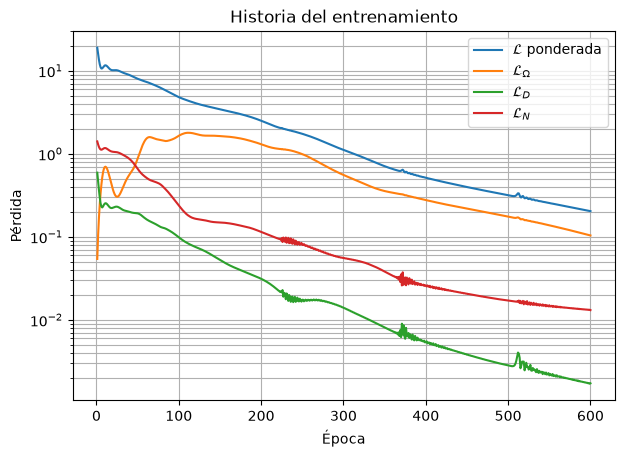

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.8))
epoch_axis = np.arange(1, EPOCHS + 1)
ax.semilogy(epoch_axis, history["total"], label=r"$\mathcal{L}$ ponderada")
ax.semilogy(epoch_axis, history["interior"], label=r"$\mathcal{L}_{\Omega}$")
ax.semilogy(epoch_axis, history["dirichlet"], label=r"$\mathcal{L}_{D}$")
ax.semilogy(epoch_axis, history["neumann"], label=r"$\mathcal{L}_{N}$")
ax.set_xlabel("Época")
ax.set_ylabel("Pérdida")
ax.set_title("Historia del entrenamiento")
ax.grid(True, which="both")
ax.legend()
plt.show()

# Parte V. Solución y diagnósticos independientes

## 10. Visualización de $u_{\theta}$

Evaluamos la red sobre una rejilla cartesiana y enmascaramos los puntos que no pertenecen al anillo. Esta rejilla no se usó para entrenar.

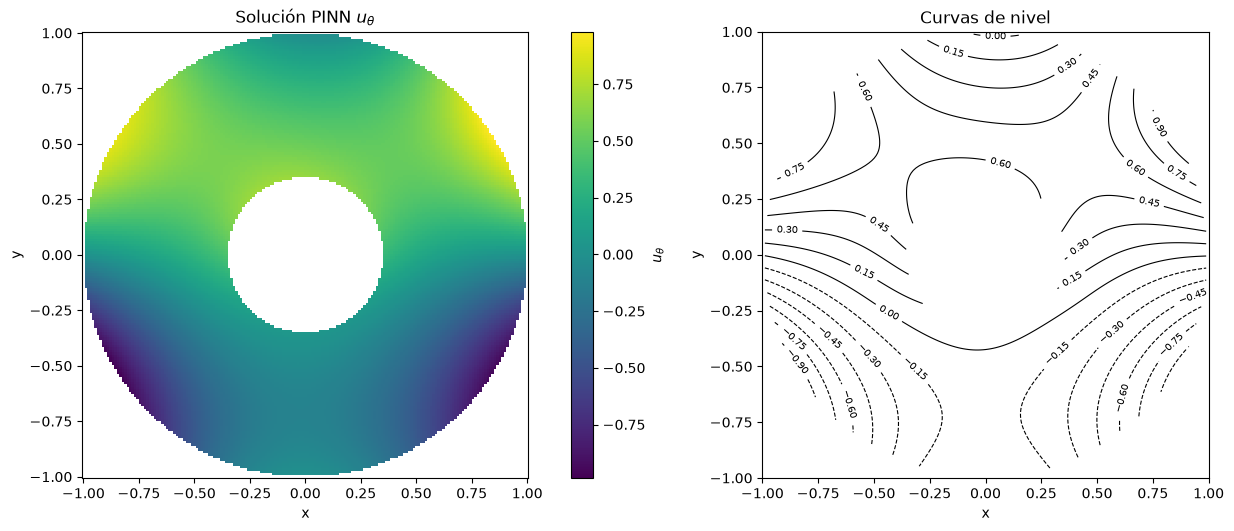

In [10]:
model.eval()
plot_values = np.linspace(-R_OUTER, R_OUTER, 181)
X, Y = np.meshgrid(plot_values, plot_values, indexing="xy")
R = np.sqrt(X**2 + Y**2)
mask = (R > R_INNER) & (R < R_OUTER)
xy_grid_np = np.column_stack((X[mask], Y[mask]))
xy_grid = torch.tensor(xy_grid_np, device=DEVICE, dtype=DTYPE)

with torch.no_grad():
    u_grid_values = model(xy_grid).cpu().numpy().ravel()

U = np.full_like(X, np.nan, dtype=float)
U[mask] = u_grid_values

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
image = axes[0].pcolormesh(X, Y, U, shading="auto")
fig.colorbar(image, ax=axes[0], label=r"$u_\theta$")
axes[0].set_title(r"Solución PINN $u_\theta$")

contours = axes[1].contour(X, Y, U, levels=18, colors="black", linewidths=0.8)
axes[1].clabel(contours, inline=True, fontsize=7)
axes[1].set_title("Curvas de nivel")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
plt.show()

## 11. Conjunto de diagnóstico independiente

Una pérdida de entrenamiento pequeña no demuestra por sí sola que la solución sea precisa. Generamos nuevos puntos y medimos por separado:

- residual interior RMS;
- defecto de Dirichlet RMS y máximo;
- defecto de Neumann RMS y máximo.

Estos diagnósticos no son errores exactos, porque no conocemos $u$.

In [11]:
def evaluate_diagnostics(model, n_interior=1400, n_boundary=320, seed=SEED + 100):
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    xy_i = sample_annulus_interior(n_interior, generator).requires_grad_(True)
    xy_d = sample_circle(R_OUTER, n_boundary, generator)
    xy_n = sample_circle(R_INNER, n_boundary, generator).requires_grad_(True)

    _, _, lap_u = laplacian(model, xy_i, create_graph=False)
    residual_i = lap_u - source_torch(xy_i)

    with torch.no_grad():
        residual_d = model(xy_d) - dirichlet_torch(xy_d)

    u_n = model(xy_n)
    grad_n = gradient_scalar_field(u_n, xy_n, create_graph=False)
    derivative_n = torch.sum(
        grad_n * inner_outward_normal(xy_n), dim=1, keepdim=True
    )
    residual_n = derivative_n - neumann_torch(xy_n)

    return {
        "interior_rms": torch.sqrt(torch.mean(residual_i.detach()**2)).item(),
        "dirichlet_rms": torch.sqrt(torch.mean(residual_d.detach()**2)).item(),
        "dirichlet_max": torch.max(torch.abs(residual_d.detach())).item(),
        "neumann_rms": torch.sqrt(torch.mean(residual_n.detach()**2)).item(),
        "neumann_max": torch.max(torch.abs(residual_n.detach())).item(),
        "xy_interior": xy_i.detach().cpu().numpy(),
        "residual_interior": residual_i.detach().cpu().numpy().ravel(),
    }


diagnostics = evaluate_diagnostics(model)
for key in [
    "interior_rms",
    "dirichlet_rms",
    "dirichlet_max",
    "neumann_rms",
    "neumann_max",
]:
    print(f"{key:18s}: {diagnostics[key]:.6e}")

interior_rms      : 4.235609e-01
dirichlet_rms     : 4.266318e-02
dirichlet_max     : 1.212777e-01
neumann_rms       : 1.133484e-01
neumann_max       : 1.963571e-01


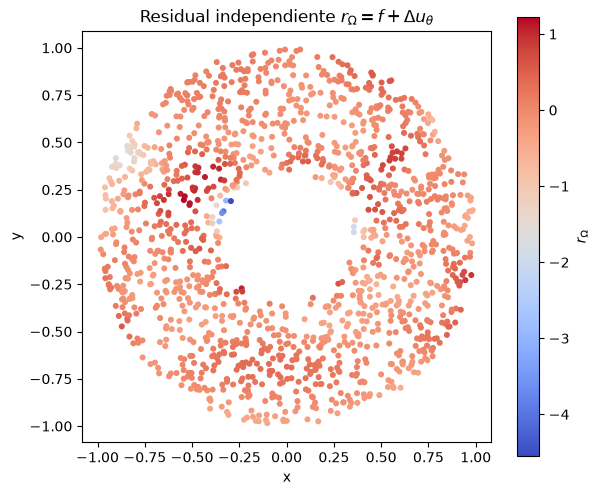

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 5.7))
residual_plot = ax.scatter(
    diagnostics["xy_interior"][:, 0],
    diagnostics["xy_interior"][:, 1],
    c=diagnostics["residual_interior"],
    s=11,
    cmap="coolwarm",
)
ax.set_title(r"Residual independiente $r_\Omega=f+\Delta u_\theta$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
fig.colorbar(residual_plot, ax=ax, label=r"$r_\Omega$")
plt.show()

## 12. Comparación con una solución FEM de referencia

Para comparar $u_{\theta}$ con otro método, resolvemos el mismo problema con `scikit-fem` sobre una malla más fina. La comparación será

$$
\|u_{\mathrm{ref}}-u_{\theta}\|,
$$

no $\|u-u_{\theta}\|$, porque $u_{\mathrm{ref}}$ también es una aproximación.

Esta sección requiere `scikit-fem`, igual que el notebook de la primera sesión.

In [13]:
from skfem import (
    MeshTri, Basis, FacetBasis, ElementTriP1,
    BilinearForm, LinearForm, asm, condense, solve,
)
from skfem.helpers import dot, grad


def make_annulus_mesh(r_inner=R_INNER, r_outer=R_OUTER, n_radial=16, n_angular=128):
    radii = np.linspace(r_inner, r_outer, n_radial + 1)
    angles = np.linspace(0.0, 2.0 * np.pi, n_angular, endpoint=False)
    points = np.array([
        (radius * np.cos(theta), radius * np.sin(theta))
        for radius in radii for theta in angles
    ]).T
    triangles = []
    for j in range(n_radial):
        for i in range(n_angular):
            i_next = (i + 1) % n_angular
            a = j * n_angular + i
            b = j * n_angular + i_next
            c = (j + 1) * n_angular + i
            d = (j + 1) * n_angular + i_next
            triangles.extend([[a, c, d], [a, d, b]])
    mesh = MeshTri(points, np.asarray(triangles, dtype=np.int32).T)
    tolerance = (r_outer - r_inner) / (4.0 * n_radial)
    return mesh.with_boundaries({
        "inner": lambda x: np.isclose(np.sqrt(x[0]**2 + x[1]**2), r_inner, atol=tolerance),
        "outer": lambda x: np.isclose(np.sqrt(x[0]**2 + x[1]**2), r_outer, atol=tolerance),
    })


def source_numpy(x, y): return x

def dirichlet_numpy(x, y): return np.sin(np.pi * y)
def neumann_numpy(x, y): return np.sqrt(x**2 + 1.0)

@BilinearForm
def fem_bilinear(u, v, w): return dot(grad(u), grad(v))

@LinearForm
def fem_volume(v, w): return -source_numpy(w.x[0], w.x[1]) * v

@LinearForm
def fem_neumann(v, w): return neumann_numpy(w.x[0], w.x[1]) * v

reference_mesh = make_annulus_mesh()
reference_basis = Basis(reference_mesh, ElementTriP1())
A_ref = asm(fem_bilinear, reference_basis)
b_ref = asm(fem_volume, reference_basis)
inner_ref = FacetBasis(reference_mesh, ElementTriP1(), facets=reference_mesh.boundaries["inner"])
b_ref += asm(fem_neumann, inner_ref)
D_ref = reference_basis.get_dofs("outer")
x_ref = np.zeros(reference_basis.N)
xy_D_ref = reference_mesh.p[:, D_ref.all()]
x_ref[D_ref.all()] = dirichlet_numpy(xy_D_ref[0], xy_D_ref[1])
u_ref = solve(*condense(A_ref, b_ref, x=x_ref, D=D_ref))

xy_ref_torch = torch.tensor(reference_mesh.p.T, device=DEVICE, dtype=DTYPE)
with torch.no_grad():
    u_theta_on_ref = model(xy_ref_torch).cpu().numpy().ravel()
reference_difference = u_theta_on_ref - u_ref

print(f"Grados de libertad de la referencia FEM: {reference_basis.N}")
print(f"Diferencia nodal RMS PINN-FEM: {np.sqrt(np.mean(reference_difference**2)):.6e}")
print(f"Diferencia nodal máxima:        {np.max(np.abs(reference_difference)):.6e}")

Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


Grados de libertad de la referencia FEM: 2176
Diferencia nodal RMS PINN-FEM: 2.367756e-02
Diferencia nodal máxima:        1.210870e-01


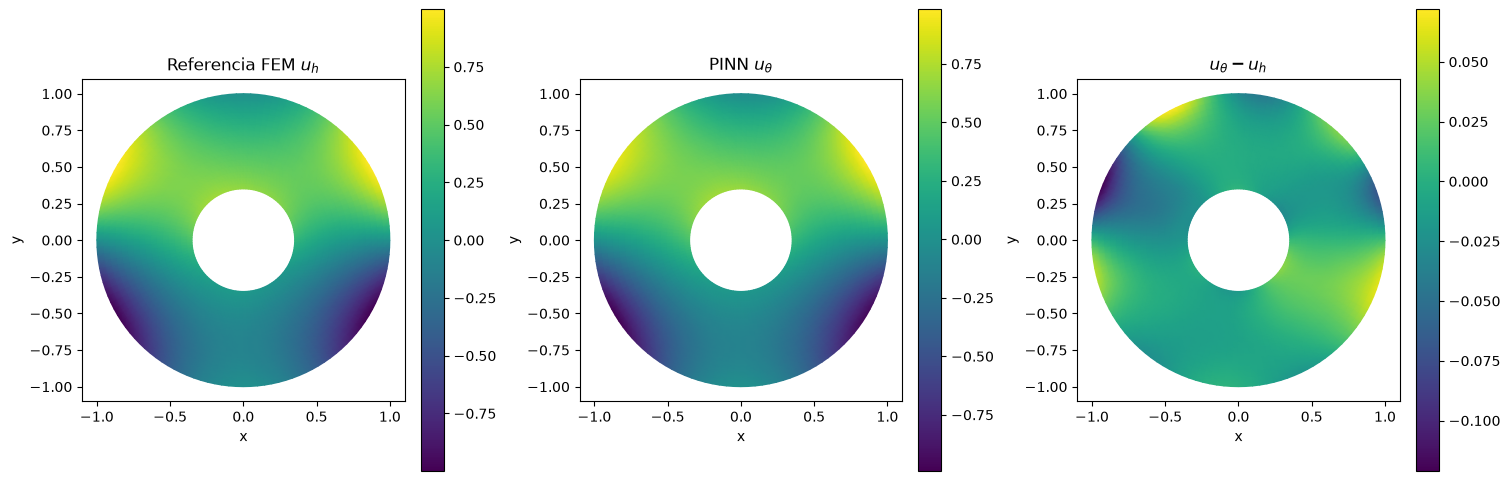

In [14]:
from matplotlib.tri import Triangulation
tri_ref = Triangulation(reference_mesh.p[0], reference_mesh.p[1], reference_mesh.t.T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
for ax, values, title in [
    (axes[0], u_ref, r"Referencia FEM $u_h$"),
    (axes[1], u_theta_on_ref, r"PINN $u_\theta$"),
    (axes[2], reference_difference, r"$u_\theta-u_h$"),
]:
    image = ax.tripcolor(tri_ref, values, shading="gouraud")
    fig.colorbar(image, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
plt.show()

# Parte VI. Relación con Deep Ritz

## 13. De la forma débil al funcional de energía

Para Poisson con Dirichlet homogénea, la solución también minimiza

$$
J[u]
=
\int_{\Omega}
\left(
\frac{1}{2}|\nabla u|^{2}+fu
\right)d\Omega.
$$

Con Neumann no homogénea aparece además el término

$$
-\int_{\Gamma_{N}}hu\,d\Gamma.
$$

Deep Ritz sustituye $u$ por $u_{\theta}$ y minimiza una aproximación Monte Carlo de ese funcional. Así se evita calcular segundas derivadas, aunque las condiciones esenciales de Dirichlet siguen requiriendo tratamiento específico.

La formulación fuerte PINN y Deep Ritz no son idénticas:

- PINN fuerte minimiza el defecto puntual de la EDP;
- Deep Ritz minimiza una energía variacional;
- ambas pueden usar una red como familia aproximante;
- ambas requieren validación independiente.

In [15]:
def deep_ritz_terms(model, xy_interior, xy_neumann):
    xy_interior = xy_interior.requires_grad_(True)
    u = model(xy_interior)
    grad_u = gradient_scalar_field(u, xy_interior, create_graph=True)
    energy_density = 0.5 * torch.sum(grad_u**2, dim=1, keepdim=True) + source_torch(xy_interior) * u

    # Muestreo uniforme en área y longitud: multiplicamos las medias por las medidas.
    area = np.pi * (R_OUTER**2 - R_INNER**2)
    circumference_inner = 2.0 * np.pi * R_INNER
    volume_term = area * torch.mean(energy_density)
    neumann_term = -circumference_inner * torch.mean(neumann_torch(xy_neumann) * model(xy_neumann))
    return volume_term, neumann_term, volume_term + neumann_term


ritz_generator = torch.Generator(device=DEVICE).manual_seed(SEED + 200)
ritz_i = sample_annulus_interior(1000, ritz_generator)
ritz_n = sample_circle(R_INNER, 240, ritz_generator)
volume_term, neumann_term, ritz_value = deep_ritz_terms(model, ritz_i, ritz_n)
print(f"Término volumétrico: {volume_term.detach().item():.6e}")
print(f"Término de Neumann:  {neumann_term.detach().item():.6e}")
print(f"J aproximado:        {ritz_value.detach().item():.6e}")
print("Nota: falta añadir una estrategia o penalización de Dirichlet para entrenar con Deep Ritz.")

Término volumétrico: 2.687855e+00
Término de Neumann:  -8.541844e-01
J aproximado:        1.833671e+00
Nota: falta añadir una estrategia o penalización de Dirichlet para entrenar con Deep Ritz.


# Parte VII. Problemas inversos

## 14. Física, datos y parámetros desconocidos

En un problema directo conocemos los parámetros y buscamos $u$. En un problema inverso algunas propiedades son desconocidas. Por ejemplo:

$$
-\kappa\Delta u=f,
$$

con $\kappa>0$ desconocido. Una PINN puede optimizar simultáneamente:

$$
u_{\theta}(\mathbf{x})
\qquad\text{y}\qquad
\kappa_{\alpha},
$$

combinando:

$$
\mathcal{L}
=
\lambda_{\Omega}\mathcal{L}_{\Omega}
+
\lambda_{D}\mathcal{L}_{D}
+
\lambda_{N}\mathcal{L}_{N}
+
\lambda_{\mathrm{data}}\mathcal{L}_{\mathrm{data}}
+
\lambda_{\mathrm{reg}}\mathcal{L}_{\mathrm{reg}}.
$$

Aquí aparece una ventaja metodológica importante: ecuaciones y observaciones pueden incorporarse al mismo problema de optimización. Eso no elimina cuestiones de identificabilidad, ruido, sesgos o incertidumbre.

In [16]:
# Demostración opcional y breve de identificación de un parámetro en 1D.
# Se deja desactivada por defecto para no consumir tiempo durante la charla.
if RUN_INVERSE_DEMO:
    torch.manual_seed(SEED + 300)
    kappa_true = 2.5
    x_data = torch.linspace(0.05, 0.95, 20, device=DEVICE).reshape(-1, 1)
    u_data = torch.sin(torch.pi * x_data) / kappa_true

    inverse_model = MLP(input_dim=1, hidden_dim=24, hidden_layers=2).to(DEVICE)
    raw_kappa = nn.Parameter(torch.tensor(0.0, device=DEVICE))
    inverse_optimizer = torch.optim.Adam(
        list(inverse_model.parameters()) + [raw_kappa], lr=2.0e-3
    )

    x_interior_inverse = torch.linspace(0.0, 1.0, 80, device=DEVICE).reshape(-1, 1)
    x_boundary_inverse = torch.tensor([[0.0], [1.0]], device=DEVICE)

    for epoch in range(1200):
        inverse_optimizer.zero_grad(set_to_none=True)
        x_i = x_interior_inverse.detach().clone().requires_grad_(True)
        u_i = inverse_model(x_i)
        u_x = torch.autograd.grad(u_i, x_i, torch.ones_like(u_i), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_i, torch.ones_like(u_x), create_graph=True)[0]
        kappa = torch.nn.functional.softplus(raw_kappa) + 1.0e-6
        residual = -kappa * u_xx - torch.pi**2 * torch.sin(torch.pi * x_i)
        loss_physics = torch.mean(residual**2)
        loss_boundary = torch.mean(inverse_model(x_boundary_inverse)**2)
        loss_data = torch.mean((inverse_model(x_data) - u_data)**2)
        loss = loss_physics + 20.0 * loss_boundary + 50.0 * loss_data
        loss.backward()
        inverse_optimizer.step()

    print(f"kappa verdadero: {kappa_true:.4f}")
    print(f"kappa inferido:  {kappa.detach().item():.4f}")
else:
    print("Demostración inversa no ejecutada. Cambia RUN_INVERSE_DEMO=True para activarla.")

Demostración inversa no ejecutada. Cambia RUN_INVERSE_DEMO=True para activarla.


# Parte VIII. Comparación científica entre FEM y PINN

## 15. Qué debemos comparar

| Aspecto | FEM | PINN |
|---|---|---|
| Representación | funciones de base locales | red neuronal global |
| Cálculo principal | sistema algebraico disperso | optimización no convexa |
| Problema directo estándar | muy robusto y eficiente | normalmente no sustituye a FEM |
| Condición Dirichlet | esencial, condensación o levantamiento | penalización blanda o construcción fuerte |
| Condición Neumann | término natural en forma débil | derivada normal en la pérdida |
| Diagnóstico | teoría de error y estimadores consolidados | pérdida, residuos, referencia y observables |
| Física más datos | formulaciones adicionales | integración natural en la pérdida |
| Reproducibilidad | alta con solver fijado | sensible a semilla e hiperparámetros |

No deben compararse únicamente los segundos de una evaluación final. En una PINN hay que contabilizar entrenamiento, selección de hiperparámetros, repeticiones y validación.

# Conclusiones

El recorrido de la segunda sesión ha sido:

$$
u_{\theta}(x,y)
\longrightarrow
\text{autodiferenciación}
\longrightarrow
r_{\Omega}=\Delta u_{\theta}-f
\longrightarrow
\mathcal{L}_{\Omega}+\mathcal{L}_{D}+\mathcal{L}_{N}
\longrightarrow
\text{optimización}
\longrightarrow
\text{diagnósticos independientes}.
$$

Puntos clave:

- una red neuronal es una función parametrizada;
- PyTorch permite derivarla respecto a las coordenadas;
- la convención $\Delta u=f$ implica $r_{\Omega}=\Delta u_{\theta}-f$;
- Dirichlet se ha impuesto de forma blanda y general;
- en la frontera interior la normal exterior apunta hacia el agujero;
- una pérdida pequeña no equivale a una solución precisa;
- la comparación con FEM usa una referencia numérica, no una solución exacta;
- Deep Ritz conecta la aproximación neuronal con la estructura variacional;
- los problemas inversos son un escenario especialmente natural para combinar física y datos.

La historia completa del curso queda:

$$
\text{EDP}
\longrightarrow
\text{formulación débil}
\longrightarrow
u_{h}
\longrightarrow
u_{\theta}
\longrightarrow
\text{PINN}
\longrightarrow
\text{problema inverso}.
$$

## Preguntas para discusión

1. ¿Por qué `Tanh` suele ser más adecuada que ReLU para una EDP de segundo orden?
2. ¿Qué ocurre si $\lambda_{D}$ es demasiado pequeño o demasiado grande?
3. ¿Puede una pérdida total pequeña ocultar un residual de Neumann grande?
4. ¿Por qué necesitamos puntos de diagnóstico que no se usaron en el entrenamiento?
5. ¿Qué diferencia matemática hay entre una PINN fuerte y Deep Ritz?
6. ¿Cuándo preferirías FEM para un problema directo?
7. ¿Qué información adicional hace identificable un parámetro desconocido?

## Trabajo posterior

- repetir el entrenamiento con varias semillas;
- observar sensibilidad a arquitectura, activación y pesos;
- comparar muestreo fijo y remuestreo por épocas;
- estudiar imposición fuerte y blanda de Dirichlet;
- ejecutar la demostración inversa opcional;
- comparar tiempos y errores medidos, nunca inventados.